In [ ]:
import pandas as pd
from pathlib import Path
from inspect_ai.log import read_eval_log
import matplotlib.pyplot as plt
from property_listing.eval.pipeline import run_eval

In [ ]:
LOG_DIR = "./logs"
RUN_PIPELINE = True

In [ ]:
"""
Run Full Pipeline
"""
if RUN_PIPELINE:
    evaluation_results = run_eval()

In [ ]:
log_path = sorted(Path(LOG_DIR).glob("*.eval"))[-1]
log = read_eval_log(str(log_path))
rows = []

for s in log.samples:
    base = {
        "id": s.id,
        "property": (s.metadata or {}).get("property"),
        "output": s.metadata["generated_copy_json"],
    }
    scores = getattr(s, "scores", {}) or {}

    for metric_name, score in scores.items():
        rows.append(
            {
                **base,
                "metric": metric_name,
                "value": score.value,
                "explanation": score.explanation,
                "audit": (score.metadata or {}).get("audit_checks", []),
            }
        )

df = pd.DataFrame(rows)
df.head()

,id,property,output,metric,value,explanation,audit
0,10482,"{'property_id': 10482, 'property_name': 'The L...","{""slug_headline"":""Sky-High Living in the Heart...",groundedness_scorer_cot,0.904762,Groundedness Score: 0.90 (19/21 claims verifie...,[{'claim': 'The property is located in Chicago...
1,10482,"{'property_id': 10482, 'property_name': 'The L...","{""slug_headline"":""Sky-High Living in the Heart...",structure_scorer,1.000000,Valid JSON + schema + structural constraints s...,[]
2,10483,"{'property_id': 10483, 'property_name': 'Seren...","{""slug_headline"":""Oceanfront Luxury Estate wit...",groundedness_scorer_cot,0.947368,Groundedness Score: 0.95 (18/19 claims verifie...,[{'claim': 'Serenity Bay Estate is located in ...
3,10483,"{'property_id': 10483, 'property_name': 'Seren...","{""slug_headline"":""Oceanfront Luxury Estate wit...",structure_scorer,1.000000,Valid JSON + schema + structural constraints s...,[]


In [37]:
metric_summary = (
    df.groupby("metric")["value"]
    .agg(["count", "mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

metric_summary

,count,mean,std,min,max
metric,,,,,
structure_scorer,2,1.000000,0.000000,1.000000,1.000000
groundedness_scorer_cot,2,0.926065,0.030127,0.904762,0.947368


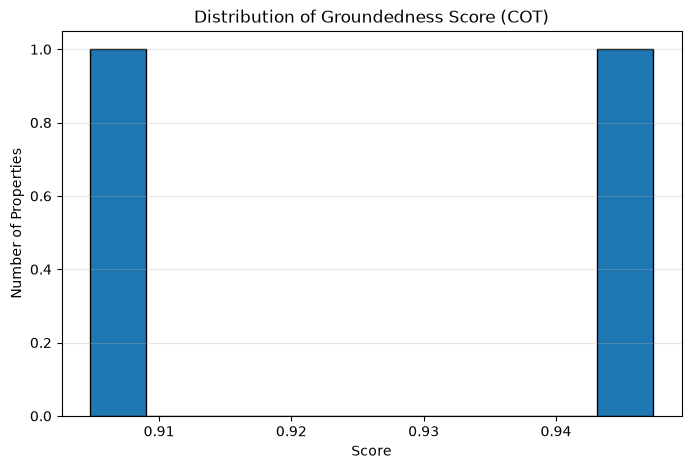

In [ ]:
import pandas as pd

metric_name = "groundedness_scorer_cot"
metric_df = df[df["metric"] == metric_name].copy()

values = pd.to_numeric(metric_df["value"], errors="coerce").dropna()

plt.figure(figsize=(8, 5))
plt.hist(values, bins=10, edgecolor="black")

plt.title("Distribution of Groundedness Score (COT)")
plt.xlabel("Score")
plt.ylabel("Number of Properties")

plt.grid(axis="y", alpha=0.3)
plt.show()

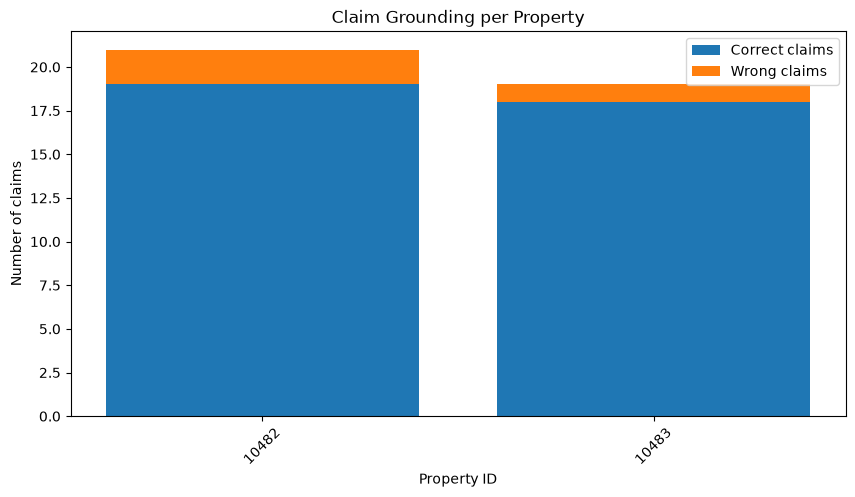

In [ ]:
metric_df = df[df["metric"] == "groundedness_scorer_cot"].copy()


def extract_counts(audit):
    if not isinstance(audit, list):
        return 0, 0
    total = len(audit)
    wrong = sum(1 for x in audit if not x.get("verdict", True))
    return wrong, total


metric_df[["wrong", "total"]] = metric_df["audit"].apply(
    lambda a: pd.Series(extract_counts(a))
)

metric_df["correct"] = metric_df["total"] - metric_df["wrong"]
metric_df["wrong_ratio"] = metric_df["wrong"] / metric_df["total"]

metric_df = metric_df.sort_values("wrong_ratio", ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(metric_df["id"], metric_df["correct"], label="Correct claims")
plt.bar(
    metric_df["id"],
    metric_df["wrong"],
    bottom=metric_df["correct"],
    label="Wrong claims",
)

plt.title("Claim Grounding per Property")
plt.xlabel("Property ID")
plt.ylabel("Number of claims")
plt.legend()

plt.xticks(rotation=45)
plt.show()